## MargNet - Experiment3 - Star-Galaxy-Quasar Classification

## Star-Galaxy-Quasar Classification (Experiment 3) using MargNet. Stacked ensemble of ANN (for Photometric features), and CNN (for images).  

#### Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
np.random.seed(69)
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.image as img
import seaborn as sns
sns.set()
# from tqdm.notebook 
import tqdm
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import time
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader


In [2]:
out_dir = "/scratch/srinadb/Foundation/Trained_Models/MargNet/Experiment3/SGQ/"
os.makedirs(out_dir, exist_ok=True)
out_dir1 = "/scratch/srinadb/Foundation/Trained_Models/MargNet/Experiment1/SGQ/"


#### 1. Load the dataset

In [3]:
dnnx_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/dnnx_sgq_exp3.npy")
X_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/X_sgq_exp3.npy")
X_test = X_test.transpose((0, 3, 1, 2))

y_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/y_sgq_exp3.npy")
# y_sg, label_strings = pd.factorize(y_sg,sort=True)
y_test = np.argmax(y_test, axis=1)
label_strings = ['GALAXY', 'QSO', 'STAR']


In [4]:
def get_metrics(y_pred, y_test, labels, to_print=True):
    correct_labels = np.where(y_pred==y_test)[0]
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred,average='macro')
    recall = metrics.recall_score(y_test, y_pred,average='macro')
    f1score = metrics.f1_score(y_test, y_pred,average='macro')
    # rocscore = metrics.roc_auc_score(y_test, y_pred,average='micro',multi_class="ovo")
    confusion_matrix = metrics.confusion_matrix(y_test, y_pred)  
    classification_report = metrics.classification_report(y_test, y_pred)

    if to_print:
        print("Identified {} correct labels out of {} labels".format(len(correct_labels), y_test.shape[0]))
        print("Accuracy:",accuracy)
        print("Precision:",precision)
        print("Recall:",recall)
        print("F1 Score:",f1score)
        # print("ROC AUC Score:",rocscore)
        print(f"Labels are: {labels}")
        print("Confusion Matrix:\n", confusion_matrix)
        print("Classification_Report:\n", classification_report)

    return (correct_labels, accuracy, precision, recall, confusion_matrix, classification_report)

### 1. ANN Model using Photometric Features

In [5]:
# Define the custom PyTorch model

class DNNModel(nn.Module):
    def __init__(self, input_dim, n_classes):
        super(DNNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 1024)
        self.dropout1 = nn.Dropout(0.25)
        # self.activation = torch.nn.sigmoid()
        self.fc2 = nn.Linear(1024, 256)
        self.dropout2 = nn.Dropout(0.25)
        self.fc3 = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(0.25)
        self.fc4 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(0.25)
        self.fc5 = nn.Linear(64, 32)
        self.dropout5 = nn.Dropout(0.25)
        self.fc6 = nn.Linear(32, n_classes)        

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = self.dropout1(x)
        x = torch.sigmoid(self.fc2(x))
        x = self.dropout2(x)
        x = torch.sigmoid(self.fc3(x))
        x = self.dropout3(x)
        x = torch.sigmoid(self.fc4(x))
        x = self.dropout4(x)
        x = torch.sigmoid(self.fc5(x))
        x = self.dropout5(x)
        x = self.fc6(x)
        return x

# Initialize the PyTorch model
pf_input_dim = dnnx_test.shape[1]
n_classes = 3
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
pf_model = DNNModel(pf_input_dim, n_classes).to(device)
        

cuda:0


### 2. CNN Model using Images

In [6]:
# Initialize the PyTorch model
in_channels = X_test.shape[1]
image_ht = X_test.shape[2]
image_wt = X_test.shape[3]

class InceptionLikeNet(nn.Module):
    def __init__(self, in_channels, img_height, img_width, num_classes=2):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)

        # First conv
        self.conv0 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)

        # --- Block 1 ---
        self.b1_c1_1x1 = nn.Conv2d(64, 48, kernel_size=1)
        self.b1_c2_1x1 = nn.Conv2d(64, 48, kernel_size=1)
        self.b1_c3_1x1 = nn.Conv2d(64, 48, kernel_size=1)
        self.b1_c4_1x1 = nn.Conv2d(48, 64, kernel_size=1)
        self.b1_c5_3x3 = nn.Conv2d(48, 64, kernel_size=3, padding=1)
        self.b1_c6_5x5 = nn.Conv2d(48, 64, kernel_size=5, padding=2)

        # shared pools
        self.pool1x1 = nn.AvgPool2d(kernel_size=1, stride=1)  # like AveragePooling2D((1,1))
        self.pool2x2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # --- Block 2 ---
        # input channels after block1 concat: 64+64+64+48 = 240
        self.b2_c7_1x1  = nn.Conv2d(240, 64, kernel_size=1)
        self.b2_c8_1x1  = nn.Conv2d(240, 64, kernel_size=1)
        self.b2_c9_1x1  = nn.Conv2d(240, 64, kernel_size=1)
        self.b2_c10_1x1 = nn.Conv2d(64, 92, kernel_size=1)
        self.b2_c11_3x3 = nn.Conv2d(64, 92, kernel_size=3, padding=1)
        self.b2_c12_5x5 = nn.Conv2d(64, 92, kernel_size=5, padding=2)
        # after concat: 92+92+92+64 = 340, then 2x2 avg pool

        # --- Block 3 ---
        self.b3_c13_1x1 = nn.Conv2d(340, 92, kernel_size=1)
        self.b3_c14_1x1 = nn.Conv2d(340, 92, kernel_size=1)
        self.b3_c15_1x1 = nn.Conv2d(340, 92, kernel_size=1)
        self.b3_c16_1x1 = nn.Conv2d(92, 128, kernel_size=1)
        self.b3_c17_3x3 = nn.Conv2d(92, 128, kernel_size=3, padding=1)
        self.b3_c18_5x5 = nn.Conv2d(92, 128, kernel_size=5, padding=2)
        # concat: 128+128+128+92 = 476

        # --- Block 4 ---
        self.b4_c19_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b4_c20_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b4_c21_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b4_c22_1x1 = nn.Conv2d(92, 128, kernel_size=1)
        self.b4_c23_3x3 = nn.Conv2d(92, 128, kernel_size=3, padding=1)
        self.b4_c24_5x5 = nn.Conv2d(92, 128, kernel_size=5, padding=2)
        # concat: 128+128+128+92 = 476, then 2x2 avg pool

        # --- Block 5 ---
        self.b5_c25_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b5_c26_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b5_c27_1x1 = nn.Conv2d(476, 128, kernel_size=1)
        self.b5_c28_3x3 = nn.Conv2d(92, 128, kernel_size=3, padding=1)
        # concat: 128+128+92 = 348

        # Dense part we need to know flattened size, so we build dynamically
        self._build_fc(in_channels, img_height, img_width, num_classes)

    # run only the conv part (up to Flatten in your Keras model)
    def _forward_features(self, x):
        x = self.relu(self.conv0(x))

        # Block 1
        c1 = self.relu(self.b1_c1_1x1(x))
        c2 = self.relu(self.b1_c2_1x1(x))
        c3 = self.relu(self.b1_c3_1x1(x))
        c4 = self.relu(self.b1_c4_1x1(c1))
        c5 = self.relu(self.b1_c5_3x3(c1))
        c6 = self.relu(self.b1_c6_5x5(c2))
        p1 = self.pool1x1(c3)
        x  = torch.cat([c4, c5, c6, p1], dim=1)      # 240 ch

        # Block 2
        c7  = self.relu(self.b2_c7_1x1(x))
        c8  = self.relu(self.b2_c8_1x1(x))
        c9  = self.relu(self.b2_c9_1x1(x))
        c10 = self.relu(self.b2_c10_1x1(c7))
        c11 = self.relu(self.b2_c11_3x3(c7))
        c12 = self.relu(self.b2_c12_5x5(c8))
        p2  = self.pool1x1(c9)
        x   = torch.cat([c10, c11, c12, p2], dim=1)  # 340 ch
        x   = self.pool2x2(x)

        # Block 3
        c13 = self.relu(self.b3_c13_1x1(x))
        c14 = self.relu(self.b3_c14_1x1(x))
        c15 = self.relu(self.b3_c15_1x1(x))
        c16 = self.relu(self.b3_c16_1x1(c13))
        c17 = self.relu(self.b3_c17_3x3(c13))
        c18 = self.relu(self.b3_c18_5x5(c14))
        p3  = self.pool1x1(c15)
        x   = torch.cat([c16, c17, c18, p3], dim=1)  # 476 ch

        # Block 4
        c19 = self.relu(self.b4_c19_1x1(x))
        c20 = self.relu(self.b4_c20_1x1(x))
        c21 = self.relu(self.b4_c21_1x1(x))
        c22 = self.relu(self.b4_c22_1x1(c19))
        c23 = self.relu(self.b4_c23_3x3(c19))
        c24 = self.relu(self.b4_c24_5x5(c20))
        p4  = self.pool1x1(c21)
        x   = torch.cat([c22, c23, c24, p4], dim=1)  # 476 ch
        x   = self.pool2x2(x)

        # Block 5
        c25 = self.relu(self.b5_c25_1x1(x))
        c26 = self.relu(self.b5_c26_1x1(x))
        c27 = self.relu(self.b5_c27_1x1(x))
        c28 = self.relu(self.b5_c28_3x3(c25))
        p5  = self.pool1x1(c26)
        x   = torch.cat([c27, c28, p5], dim=1)       # 348 ch

        return x

    def _build_fc(self, in_channels, img_height, img_width, num_classes):
        # run a dummy tensor through conv part to figure out Flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, img_height, img_width)
            feats = self._forward_features(dummy)
            flatten_dim = feats.view(1, -1).shape[1]

        self.flatten = nn.Flatten()
        # Keras: Flatten -> Dense(1024) -> Dense(1024) -> Dense(2, softmax)
        # (no activations between Dense in your code; keeping that)
        self.fc1 = nn.Linear(flatten_dim, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self._forward_features(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        logits = self.fc3(x)   # raw scores; use CrossEntropyLoss (includes softmax)
        return logits

image_model = InceptionLikeNet(in_channels=in_channels, img_height=image_ht, img_width=image_wt, num_classes=n_classes).to(device)


### 3. Ensemble Model (ANN+CNN) using photometric features and Images

In [7]:
cnnclassifier = image_model
dnnclassifier = pf_model

In [8]:
checkpoint_image = torch.load(os.path.join(out_dir1, 'EX1_SGQ_MargNet_CNN_Model.pth'))
checkpoint_pf = torch.load(os.path.join(out_dir1, 'EX1_SGQ_MargNet_DNN_Model.pth'))


In [9]:
cnnclassifier.load_state_dict(checkpoint_image)
dnnclassifier.load_state_dict(checkpoint_pf)

<All keys matched successfully>

In [10]:
class StackedModel(nn.Module):
    def __init__(self, members):
        super(StackedModel, self).__init__()
        self.members = nn.ModuleList(members)

        # Create a dictionary to store renamed parameters
        renamed_params = {}

        # Freeze the layers and rename them
        for i, model in enumerate(self.members):
            for name, param in model.named_parameters():
                param.requires_grad = False
                new_name = f'ensemble_{i+1}_{name.replace(".", "_")}'  # Replace '.' with '_'
                renamed_params[new_name] = param

        # Apply the changes to the model outside the loop
        for i, model in enumerate(self.members):
            for new_name, param in renamed_params.items():
                setattr(model, new_name, param)

        # Define multi-headed input
        self.ensemble_visible = [model for model in self.members]

        # Concatenate the outputs from each model
        self.hidden = nn.Linear(len(members) * 3, 10)
        self.output = nn.Linear(10, 3)

    def forward(self, inputs):
        outputs = [model(inputs[i]) for i, model in enumerate(self.members)]
        merge = torch.cat(outputs, dim=1)
        hidden = torch.relu(self.hidden(merge))
        output = self.output(hidden)
        return output


In [11]:
# Create the ensemble model
members = [cnnclassifier, dnnclassifier]
model = StackedModel(members).to(device)


#### Testing the Model

In [12]:
# Convert data to PyTorch tensors and create DataLoader
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
dnnx_test_tensor = torch.tensor(dnnx_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

dataset1 = TensorDataset(X_test_tensor, dnnx_test_tensor, y_test_tensor)
dataloader1 = DataLoader(dataset1, batch_size=512, shuffle=False)


Identified 21045 correct labels out of 28532 labels
Accuracy: 0.7375928781718772
Precision: 0.7673071853037486
Recall: 0.7375872378001409
F1 Score: 0.733391180037779
Labels are: ['GALAXY', 'QSO', 'STAR']
Confusion Matrix:
 [[9165  291   55]
 [3722 5484  304]
 [1001 2114 6396]]
Classification_Report:
               precision    recall  f1-score   support

           0       0.66      0.96      0.78      9511
           1       0.70      0.58      0.63      9510
           2       0.95      0.67      0.79      9511

    accuracy                           0.74     28532
   macro avg       0.77      0.74      0.73     28532
weighted avg       0.77      0.74      0.73     28532

(array([    0,     1,     2, ..., 28513, 28522, 28524]), 0.7375928781718772, 0.7673071853037486, 0.7375872378001409, array([[9165,  291,   55],
       [3722, 5484,  304],
       [1001, 2114, 6396]]), '              precision    recall  f1-score   support\n\n           0       0.66      0.96      0.78      9511\n    

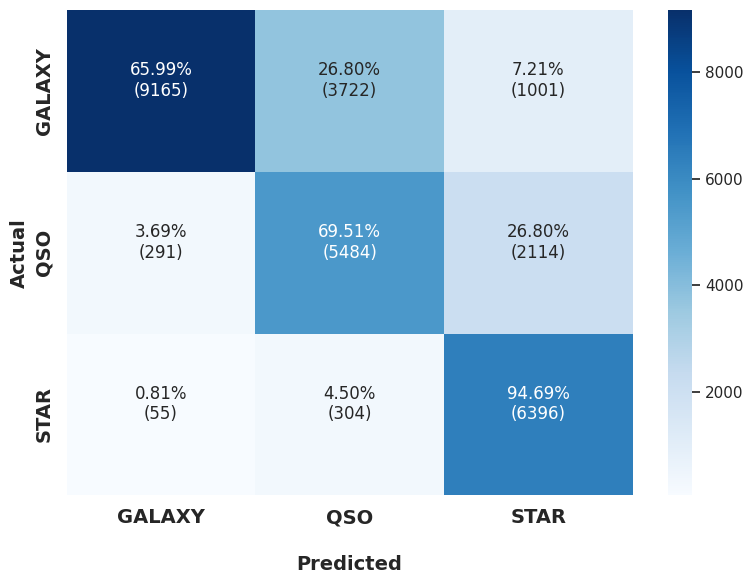

In [13]:
# Set the model to evaluation mode
        
model.load_state_dict(torch.load(os.path.join(out_dir1, 'EX1_SGQ_MargNet_Model.pth'), map_location=device))
model.eval()

y_test_pred = torch.empty(0).to(device)

# Generate predictions
with torch.no_grad():
    for images, pfs, labels in dataloader1:
        images = images.to(device)
        pfs = pfs.to(device)
        labels = labels.to(device)
        pred = model([images, pfs])

        y_test_pred = torch.cat((y_test_pred, pred), dim=0)

y_test_pred = y_test_pred.cpu().numpy()
y_test_pred = y_test_pred.argmax(axis=1)
print(get_metrics(y_test_pred, y_test, label_strings))

# https://www.stackvidhya.com/plot-confusion-matrix-in-python-and-why/#google_vignette
# fig = plt.figure()
cf_matrix = metrics.confusion_matrix(y_test_pred, y_test)
cf_matrix_percentage = metrics.confusion_matrix(y_test_pred, y_test, normalize='true')
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cf_matrix_percentage.flatten()]
labels = [f"{v1}\n({v2})\n" for v1, v2 in
          zip(group_percentages,group_counts)]
labels = np.asarray(labels).reshape(3,3)
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust the size as needed

ax = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')
ax.set_xlabel('\nPredicted', fontsize=14, weight='bold')
ax.set_ylabel('Actual', fontsize=14, weight='bold');
ax.xaxis.set_ticklabels(['GALAXY', 'QSO','STAR'], fontsize=14, weight='bold')
ax.yaxis.set_ticklabels(['GALAXY', 'QSO','STAR'], fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "EX3_SGQ_MargNet_CM.png"))

plt.show()
plt.close()

## Result Analysis

In [14]:
del(dnnx_test, X_test, y_test)

In [15]:
X = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/X_exp1.npy")
dnnx = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/dnnx_exp1.npy")
objlist = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/objlist_exp1.npy")
y = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/y_exp1.npy", allow_pickle=True)

y, label_strings = pd.factorize(y,sort=True)
# y = to_categorical(y)
print('\n')
print(label_strings)

zipX = list(zip(X, dnnx))
zipy = list(zip(y, objlist))

zipX_train, zipX_test, zipy_train, zipy_test = train_test_split(zipX, zipy, test_size = 0.125,random_state=42)
zipX_train, zipX_val, zipy_train, zipy_val = train_test_split(zipX_train, zipy_train, test_size = 0.1428, random_state=42)

X_train, dnnx_train = zip(*zipX_train)
X_val, dnnx_val = zip(*zipX_val)
X_test, dnnx_test = zip(*zipX_test)

y_train, objlist_train = zip(*zipy_train)
y_val, objlist_val = zip(*zipy_val)
y_test, objlist_test = zip(*zipy_test)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

dnnx_train = np.array(dnnx_train)
dnnx_val = np.array(dnnx_val)
dnnx_test = np.array(dnnx_test)

y_train = np.array(y_train)
objlist_train = np.array(objlist_train)
y_val = np.array(y_val)
objlist_val = np.array(objlist_val)
y_test = np.array(y_test)
objlist_test = np.array(objlist_test)

del(zipX,zipX_test,zipX_train,zipX_val, X, zipy, zipy_test, zipy_train, zipy_val, objlist, X_test, y_test, dnnx_test)

dnnx_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/dnnx_sgq_exp3.npy")
X_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/X_sgq_exp3.npy")
y_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/y_sgq_exp3.npy")
y_test = np.argmax(y_test, axis=1)

X_train = X_train.transpose((0, 3, 1, 2))
X_val = X_val.transpose((0, 3, 1, 2))
X_test = X_test.transpose((0, 3, 1, 2))

print('\n')
print('The shape of the Train data is:', X_train.shape)
print('The shape of the Validation data is:', X_val.shape)
print('The shape of the Test data is:', X_test.shape)

# Convert data to PyTorch tensors and create DataLoader
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
dnnx_train_tensor = torch.tensor(dnnx_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
dnnx_val_tensor = torch.tensor(dnnx_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
dnnx_test_tensor = torch.tensor(dnnx_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, dnnx_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False)

val_dataset = TensorDataset(X_val_tensor, dnnx_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, dnnx_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)





['GALAXY' 'QSO' 'STAR']


The shape of the Train data is: (180011, 5, 32, 32)
The shape of the Validation data is: (29988, 5, 32, 32)
The shape of the Test data is: (28532, 5, 32, 32)


In [16]:
def get_preds(loader):
    model.eval()
    all_logits = []

    with torch.no_grad():
        for images, pf, labels in loader:
            pf = pf.to(device)
            images = images.to(device)
            logits = model([images, pf])      # [batch, 3]
            all_logits.append(logits.cpu())

    all_logits = torch.cat(all_logits, dim=0)   # [N, 3]
    all_probs  = F.softmax(all_logits, dim=1)   # probabilities, rows sum to 1
    all_probs  = all_probs.numpy()

    pred_labels = all_probs.argmax(axis=1)
    return all_probs, pred_labels

preds_train, y_train_pred = get_preds(train_loader)
print(get_metrics(y_train_pred, y_train, label_strings))
print('\n')

preds_val, y_val_pred = get_preds(val_loader)
print(get_metrics(y_val_pred, y_val, label_strings))
print('\n')

preds_test, y_test_pred = get_preds(test_loader)
print(get_metrics(y_test_pred, y_test, label_strings))



Identified 168576 correct labels out of 180011 labels
Accuracy: 0.9364761042380744
Precision: 0.9365389237475802
Recall: 0.9364646835485037
F1 Score: 0.9364967662773839
Labels are: ['GALAXY' 'QSO' 'STAR']
Confusion Matrix:
 [[57545  1914   602]
 [ 1725 55055  3182]
 [  624  3388 55976]]
Classification_Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     60061
           1       0.91      0.92      0.92     59962
           2       0.94      0.93      0.93     59988

    accuracy                           0.94    180011
   macro avg       0.94      0.94      0.94    180011
weighted avg       0.94      0.94      0.94    180011

(array([     0,      1,      2, ..., 180008, 180009, 180010]), 0.9364761042380744, 0.9365389237475802, 0.9364646835485037, array([[57545,  1914,   602],
       [ 1725, 55055,  3182],
       [  624,  3388, 55976]]), '              precision    recall  f1-score   support\n\n           0       0.96      0.96 

In [17]:
df  = pd.read_csv("/scratch/srinadb/Foundation/Dataset/Experiment1/photofeatures_exp1.csv", index_col=0)
df1 = pd.read_csv("/scratch/srinadb/Foundation/Dataset/Experiment3/photofeatures_exp3.csv", index_col=0)

objlist_test = df1.index.tolist()

df.loc[objlist_train, ["set"]] = "TRAIN"
df.loc[objlist_val, ["set"]] = "VALIDATION"
df1.loc[objlist_test, ["set"]] = "TEST"

df.loc[objlist_train, ["pred_class"]] = label_strings[preds_train.argmax(axis=1)]
df.loc[objlist_val, ["pred_class"]] = label_strings[preds_val.argmax(axis=1)]
df1.loc[objlist_test, ["pred_class"]] = label_strings[preds_test.argmax(axis=1)]

pgal_train = preds_train[:,np.where(label_strings=="GALAXY")[0][0]]
pstar_train = preds_train[:,np.where(label_strings=="STAR")[0][0]]
pqso_train = preds_train[:np.where(label_strings=="QSO")[0][0]]

pgal_val = preds_val[:,np.where(label_strings=="GALAXY")[0][0]]
pstar_val = preds_val[:,np.where(label_strings=="STAR")[0][0]]
pqso_val = preds_val[:np.where(label_strings=="QSO")[0][0]]

pgal_test = preds_test[:,np.where(label_strings=="GALAXY")[0][0]]
pstar_test = preds_test[:,np.where(label_strings=="STAR")[0][0]]
pqso_test = preds_test[:np.where(label_strings=="QSO")[0][0]]

df_tv   = df.loc[list(objlist_train) + list(objlist_val)].copy()
df_test = df1.loc[objlist_test].copy()

df_all = pd.concat([df_tv, df_test], axis=0)
df_all.to_csv(os.path.join(out_dir, "EX3_SGQ_MargNet_results.csv"))


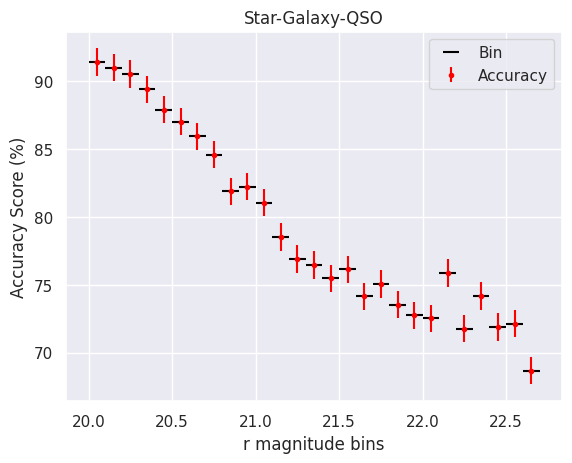

In [18]:
sns.set_palette("tab10")
df = pd.read_csv(os.path.join(out_dir, "EX3_SGQ_MargNet_results.csv"))

subdflist = []

bin_size = 0.1
lower_bin_list = np.arange(20,23,bin_size)
bad_lower_bin=[]
acclist = []
f1list = []
reportlist = []
num_samplelist = []
starmaglist = []
galmaglist = []
qsomaglist = []

for lower_bin in lower_bin_list:
#     print(f"******************** {lower_bin} < r <= {lower_bin+bin_size} ********************")
    subdf = df[(
        ((df["dered_r"]+df["extinction_r"]) > lower_bin) & 
        ((df["dered_r"]+df["extinction_r"]) <= lower_bin+bin_size)
    )]
    # Choose equal number of stars, galaxies and qsos
    min_num = subdf["class"].value_counts().min()
    if min_num < 50:
        bad_lower_bin.append(lower_bin)
        continue
    s1 = subdf[subdf["class"]=="GALAXY"].sample(n=min_num)
    galmaglist.append((s1["dered_r"]+s1["extinction_r"]).to_numpy())
    s2 = subdf[subdf["class"]=="STAR"].sample(n=min_num)
    starmaglist.append((s2["dered_r"]+s2["extinction_r"]).to_numpy())
    s3 = subdf[subdf["class"]=="QSO"].sample(n=min_num)
    qsomaglist.append((s2["dered_r"]+s2["extinction_r"]).to_numpy())
    num_samplelist.append(min_num)
    subdf = pd.concat([s1,s2,s3])
    subdflist.append(subdf)
    
    accuracy = metrics.accuracy_score(subdf["class"], subdf["pred_class"])
    f1score = metrics.f1_score(subdf["class"], subdf["pred_class"],average='macro')
    report = metrics.classification_report(subdf["class"], subdf["pred_class"],output_dict=True)
    reportlist.append(report)
    acclist.append(accuracy)
    f1list.append(f1score)
    
bad_lower_bin = np.array(bad_lower_bin)
lower_bin_list = lower_bin_list[~np.in1d(lower_bin_list,bad_lower_bin)]
# elems in lower_bin_list not in bad_lower_bin

galmaglist = np.concatenate(galmaglist)

starmaglist = np.concatenate(starmaglist)

qsomaglist = np.concatenate(qsomaglist)
plt.errorbar(lower_bin_list+bin_size/2, np.array(acclist)*100, xerr=bin_size/2, fmt=" ",color="black",label="Bin")
plt.errorbar(lower_bin_list+bin_size/2, np.array(acclist)*100, yerr=0.01*100,fmt=".",color="red",label="Accuracy")
# plt.errorbar(lower_bin_list+bin_size/2, f1list, yerr=0.01,label="F1 Score")
plt.legend()
plt.title("Star-Galaxy-QSO")
plt.xlabel("r magnitude bins")
plt.ylabel("Accuracy Score (%)")
plt.savefig(os.path.join(out_dir, "EX3_SGQ_MargNet_v2.png")) 


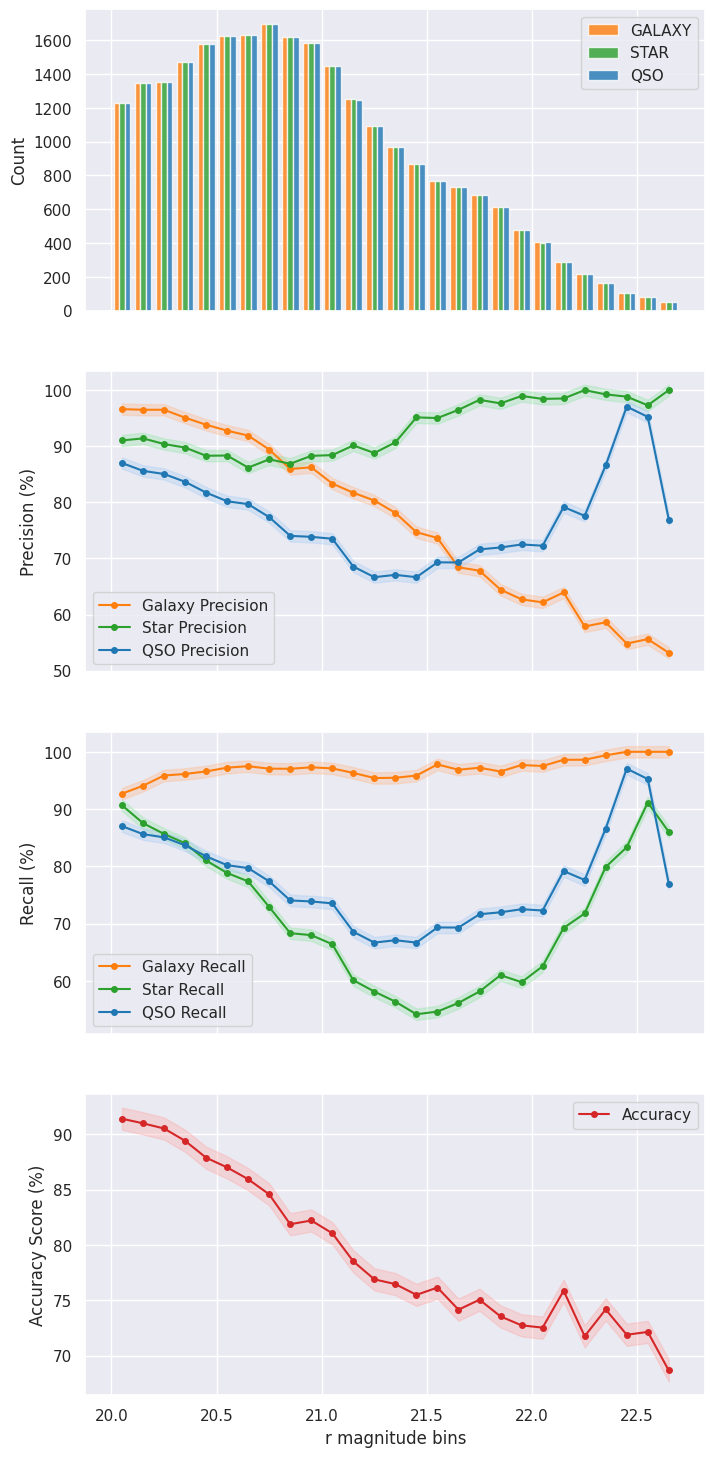

In [19]:
subdfs = pd.concat(subdflist)
subdfs["r"]=subdfs["dered_r"]+subdfs["extinction_r"]
gal_recall_list = []
gal_precision_list = []
star_recall_list = []
star_precision_list = []
qso_precision_list = []
qso_recall_list = []
for r in reportlist:
    gal_recall_list.append(r["GALAXY"]["recall"])
    gal_precision_list.append(r["GALAXY"]["precision"])
    star_recall_list.append(r["STAR"]["recall"])
    star_precision_list.append(r["STAR"]["precision"])
    qso_recall_list.append(r["QSO"]["recall"])
    qso_precision_list.append(r["QSO"]["precision"])
    
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1,sharex=True, figsize=(8,18))

galcolor = sns.color_palette("tab10")[1]
starcolor = sns.color_palette("tab10")[2]
qsocolor = sns.color_palette("tab10")[0]
acccolor = sns.color_palette("tab10")[3]
f1color = sns.color_palette("tab10")[4]

dyfit = 0.01
x_ax = lower_bin_list+bin_size/2


d1 = subdfs[subdfs["class"]=="GALAXY"]["r"]
d2 = subdfs[subdfs["class"]=="STAR"]["r"]
d3 = subdfs[subdfs["class"]=="QSO"]["r"]

ax1.hist([d1, d2, d3], color=[galcolor,starcolor, qsocolor],
         alpha=0.8, label=["GALAXY","STAR","QSO"],bins=len(lower_bin_list))
ax1.set_ylabel("Count")

ax1.legend()


y_ax1 = np.array(gal_precision_list)
y_ax2 = np.array(star_precision_list)
y_ax3 = np.array(qso_precision_list)

ax2.errorbar(x_ax, y_ax1*100,fmt="-o", ms=4, label="Galaxy Precision",color=galcolor)
ax2.fill_between(x_ax, y_ax1*100 - dyfit*100, y_ax1*100 + dyfit*100,
             color=sns.color_palette("pastel")[1], alpha=0.3)
ax2.errorbar(x_ax, y_ax2*100,fmt="-o", ms=4, label="Star Precision",color=starcolor)
ax2.fill_between(x_ax, y_ax2*100 - dyfit*100, y_ax2*100 + dyfit*100,
                 color=sns.color_palette("pastel")[2], alpha=0.3)
ax2.errorbar(x_ax, y_ax3*100,fmt="-o", ms=4, label="QSO Precision",color=qsocolor)
ax2.fill_between(x_ax, y_ax3*100 - dyfit*100, y_ax3*100 + dyfit*100,
                 color=sns.color_palette("pastel")[0], alpha=0.3)
ax2.set_ylabel("Precision (%)")
ax2.legend()

y_ax1 = np.array(gal_recall_list)
y_ax2 = np.array(star_recall_list)
y_ax3 = np.array(qso_precision_list)

ax3.errorbar(x_ax, y_ax1*100,fmt="-o", ms=4, label="Galaxy Recall",color=galcolor)
ax3.fill_between(x_ax, y_ax1*100 - dyfit*100, y_ax1*100 + dyfit*100,
             color=sns.color_palette("pastel")[1], alpha=0.3)
ax3.errorbar(x_ax, y_ax2*100,fmt="-o", ms=4, label="Star Recall",color=starcolor)
ax3.fill_between(x_ax, y_ax2*100 - dyfit*100, y_ax2*100 + dyfit*100,
             color=sns.color_palette("pastel")[2], alpha=0.3)
ax3.errorbar(x_ax, y_ax3*100,fmt="-o", ms=4, label="QSO Recall",color=qsocolor)
ax3.fill_between(x_ax, y_ax3*100 - dyfit*100, y_ax3*100 + dyfit*100,
             color=sns.color_palette("pastel")[0], alpha=0.3)
ax3.set_ylabel("Recall (%)")
ax3.legend()



y_ax1 = np.array(acclist)
y_ax2 = np.array(f1list)
ax4.errorbar(x_ax, y_ax1*100,fmt="-o", ms=4, label="Accuracy",color=acccolor)
# ax4.errorbar(x_ax, y_ax2*100,fmt="-o", ms=4, label="F1 Score",color=f1color)
ax4.fill_between(x_ax, y_ax1*100 - dyfit*100, y_ax1*100 + dyfit*100,
             color=sns.color_palette("pastel")[3], alpha=0.3)
ax4.set_ylabel("Accuracy Score (%)")
ax4.legend()

plt.xlabel("r magnitude bins")


# plt.suptitle("Star-Galaxy-QSO")
plt.savefig(os.path.join(out_dir, "EX3_SGQ_MargNet_v2Set.png")) 
plt.show()